# Speed comparision at x86-64 and ARMv8 platform

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate a speed comparision diagram for model 1a (exponential distribution) shown in the report.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Files to process

In [19]:
# AMD Ryzen 9 3900XT, Windows 25H2 /  Intel Core Ultra 5 255H (Arrow Lake), NUC 15 Pro, Kubuntu 26.04
amd_intel = {"input": [
    {"name": "Exponential distribution", "file_ryzen": "statistics/results1Exp.txt", "file_other": "statistics/results1Exp-intel.txt"},
    {"name": "Log-normal distribution", "file_ryzen": "statistics/results1Log.txt", "file_other": "statistics/results1Log-intel.txt"},
    {"name": "Gamma distribution", "file_ryzen": "statistics/results1Gamma.txt", "file_other": "statistics/results1Gamma-intel.txt"},
    {"name": "Triangular distribution", "file_ryzen": "statistics/results1Triangular.txt", "file_other": "statistics/results1Triangular-intel.txt"},
    {"name": "Poisson distribution", "file_ryzen": "statistics/results1Poisson.txt", "file_other": "statistics/results1Poisson-intel.txt"},
    {"name": "Geometric distribution", "file_ryzen": "statistics/results1Geometric.txt", "file_other": "statistics/results1Geometric-intel.txt"},
], "platform_other": "Intel Core Ultra 5 255H\n(x86-64)"}

# AMD Ryzen 9 3900XT, Windows 25H2 /  Raspberry Pi 4B
amd_arm = {"input": [
    {"name": "Exponential distribution", "file_ryzen": "statistics/results1Exp.txt", "file_other": "statistics/results1Exp-raspberrypi.txt"},
    {"name": "Log-normal distribution", "file_ryzen": "statistics/results1Log.txt", "file_other": "statistics/results1Log-raspberrypi.txt"},
    {"name": "Gamma distribution", "file_ryzen": "statistics/results1Gamma.txt", "file_other": "statistics/results1Gamma-raspberrypi.txt"},
    {"name": "Triangular distribution", "file_ryzen": "statistics/results1Triangular.txt", "file_other": "statistics/results1Triangular-raspberrypi.txt"},
], "platform_other": "Raspberry Pi 4B\n(ARMv8)"}

## Load and process data

In [20]:
def load_files(data):
    # Load files
    for rec in data["input"]:
        rec["df_ryzen"] = pd.read_csv(rec["file_ryzen"], header=None, names=["rng_mode", "n", "mean", "std", "delta2", "time"], sep="\t")
        rec["df_other"] = pd.read_csv(rec["file_other"], header=None, names=["rng_mode", "n", "mean", "std", "delta2", "time"], sep="\t")

    # Build generator names list
    df_ryzen_modes = data["input"][0]["df_ryzen"]["rng_mode"]
    df_other_modes = data["input"][0]["df_ryzen"]["rng_mode"]
    data["generators"] = list(set(df_ryzen_modes.drop_duplicates().tolist()) & set(df_other_modes.drop_duplicates().tolist()))


def process_data(data):
    generators = data["generators"]

    for rec in data["input"]:
        # Mean value per generator (100 runs were done per generator)
        times_ryzen = []
        times_other = []
        for generator in generators:
            times_ryzen.append(rec["df_ryzen"][rec["df_ryzen"]["rng_mode"] == generator]["time"].mean())
            times_other.append(rec["df_other"][rec["df_other"]["rng_mode"] == generator]["time"].mean())

        # Data frame consisting of generator name and time
        df_times_ryzen = pd.DataFrame({"generator": generators, "time_ryzen": times_ryzen}, index=generators)
        df_times_other = pd.DataFrame({"generator": generators, "time_other": times_other}, index=generators)
        rec["df_times_ryzen"] = df_times_ryzen
        rec["df_times_other"] = df_times_other

        # Sorted data frame
        df_times_ryzen_sorted = df_times_ryzen.sort_values("time_ryzen", ascending=True).reset_index(drop=True)
        df_times_other_sorted = df_times_other.sort_values("time_other", ascending=True).reset_index(drop=True)

        # Get fastest time for x86-64 and other platform (to display percent values in diagram)
        rec["fastest_time_ryzen"] = df_times_ryzen_sorted.iloc[0]["time_ryzen"]
        rec["fastest_time_other"] = df_times_other_sorted.iloc[0]["time_other"]

        # Add index
        df_times_ryzen_sorted["rank_ryzen"] = df_times_ryzen_sorted.index + 1
        df_times_other_sorted["rank_other"] = df_times_other_sorted.index + 1

        # Merge data for x86-64 and other platform
        rec["df_merged"] = pd.merge(df_times_ryzen_sorted[["generator", "time_ryzen", "rank_ryzen"]], df_times_other_sorted[["generator", "time_other", "rank_other"]], on="generator")

    # Summing up times for average comparison
    sum_times_ryzen = data["input"][0]["df_times_ryzen"].copy()["time_ryzen"]
    for i in range(1, len(data["input"])):
        sum_times_ryzen = sum_times_ryzen + data["input"][i]["df_times_ryzen"]["time_ryzen"]

    sum_times_other = data["input"][0]["df_times_other"].copy()["time_other"]
    for i in range(1, len(data["input"])):
        sum_times_other = sum_times_other + data["input"][i]["df_times_other"]["time_other"]

    sum_times_ryzen = pd.DataFrame({"generator": generators, "time_ryzen": sum_times_ryzen}, index=generators)
    sum_times_other = pd.DataFrame({"generator": generators, "time_other": sum_times_other}, index=generators)

    # Sorted data frame
    sum_times_ryzen_sorted = sum_times_ryzen.sort_values("time_ryzen", ascending=True).reset_index(drop=True)
    sum_times_other_sorted = sum_times_other.sort_values("time_other", ascending=True).reset_index(drop=True)

    # Get fastest time for x86-64 and other platform (to display percent values in diagram)
    fastest_sum_time_ryzen = sum_times_ryzen_sorted.iloc[0]["time_ryzen"]
    fastest_sum_time_other = sum_times_other_sorted.iloc[0]["time_other"]

    # Add index
    sum_times_ryzen_sorted["rank_ryzen"] = sum_times_ryzen_sorted.index + 1
    sum_times_other_sorted["rank_other"] = sum_times_other_sorted.index + 1

    # Merge data for x86-64 and other platform
    sum_merged = pd.merge(sum_times_ryzen_sorted[["generator", "time_ryzen", "rank_ryzen"]], sum_times_other_sorted[["generator", "time_other", "rank_other"]], on="generator")

    # Data frame for average of all distributions
    data["average"] = {"df_merged": sum_merged, "fastest_time_ryzen": fastest_sum_time_ryzen, "fastest_time_other": fastest_sum_time_other, "name": "Average of all distributions"}


load_files(amd_intel)
load_files(amd_arm)
process_data(amd_intel)
process_data(amd_arm)

### Colors for generator types

In [21]:
def color_from_name(name):
    if name in ['SecureRandom', 'ISAAC']:
        return 'blue'
    if name in ['Drand48', 'Drand48Mix']:
        return 'red'
    return 'black'

is_reflection=["XoRoShiRo256++", "L64X128Mix", "L64X128**", "L64X256Mix", "L64X1024Mix", "L128X128Mix", "L128X256Mix", "L128X1024Mix"]

def gen_full_name(generator):
    if generator=="ThreadLocalRandomSlow":
        return "ThreadLocalRandom.current() (**)"
    if generator in is_reflection:
        return generator+" (*)"
    return generator

## Generate diagram

In [22]:
def build_diagram(df_merged, fastest_time_ryzen, fastest_time_other, title, label_other_platform):
    # For the diagram: left x position = 0, right x position = 1
    x_left, x_right = 0, 1

    fig, ax = plt.subplots(figsize=(6, 8))

    for _, row in df_merged.iterrows():
        # Get data for generator
        time_left = round(row["time_ryzen"] / fastest_time_ryzen * 100)
        time_right = round(row["time_other"] / fastest_time_other * 100)
        y_left = row["rank_ryzen"]
        y_right = row["rank_other"]
        gen = row["generator"]

        # Average rank (for color of connection line)
        average_rank = (row["rank_other"] + row["rank_ryzen"]) / (len(df_merged) * 2)
        if average_rank < 0.25:
            color = "green"
        elif average_rank < 0.50:
            color = "gray"
        elif average_rank < 0.75:
            color = "orange"
        else:
            color = "red"

        # Connection line
        verts = [(x_left, y_left), (0.5, y_left), (0.5, y_right), (x_right, y_right)]
        codes = [patches.Path.MOVETO, patches.Path.CURVE4, patches.Path.CURVE4, patches.Path.CURVE4]  # pyright: ignore[reportAttributeAccessIssue]
        path = patches.Path(verts, codes)  # pyright: ignore[reportAttributeAccessIssue]
        patch = patches.PathPatch(path, edgecolor=color, facecolor="none", alpha=0.7)
        ax.add_patch(patch)

        # Points
        # ax.scatter([x_left], [y_left], color="blue", s=30)
        # ax.scatter([x_right], [y_right], color="red", s=30)

        # Labels
        ax.text(x_left - 0.02, y_left, gen_full_name(gen) + " (" + str(time_left) + "%)", ha="right", va="center", color=color_from_name(gen))
        ax.text(x_right + 0.02, y_right, gen_full_name(gen) + " (" + str(time_right) + "%)", ha="left", va="center", color=color_from_name(gen))

    # Setup axis
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(0.5, len(df_merged) + 0.5)
    ax.invert_yaxis()  # Rang 1 at top

    ax.set_xticks([x_left, x_right])
    ax.set_xticklabels(["Ryzen 9 3900XT\n(x86-64)", label_other_platform], fontsize=12)

    ax.set_yticks([])  # no y axis labels

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.set_title(title)

    return fig


def build_diagram_from_rec(rec, label_other_platform):
    return build_diagram(
        rec["df_merged"],
        rec["fastest_time_ryzen"],
        rec["fastest_time_other"],
        rec["name"],
        label_other_platform
    )

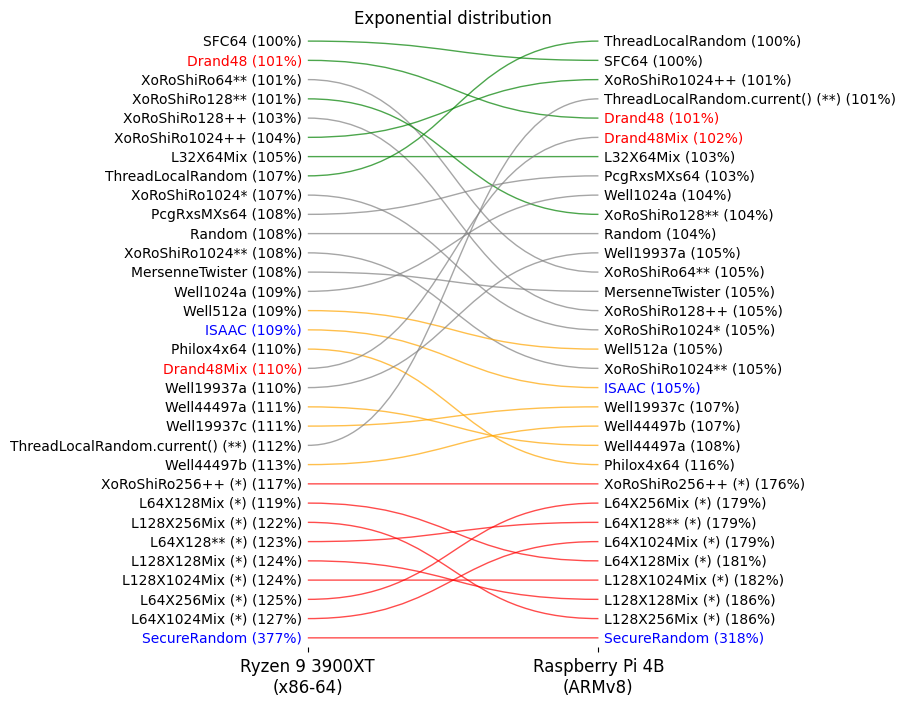

In [23]:
fig = build_diagram_from_rec(amd_arm["input"][0], amd_arm["platform_other"])

# fig.savefig("plot1platforms-Arm-Exp.png", format="png", bbox_inches='tight', pad_inches=0)

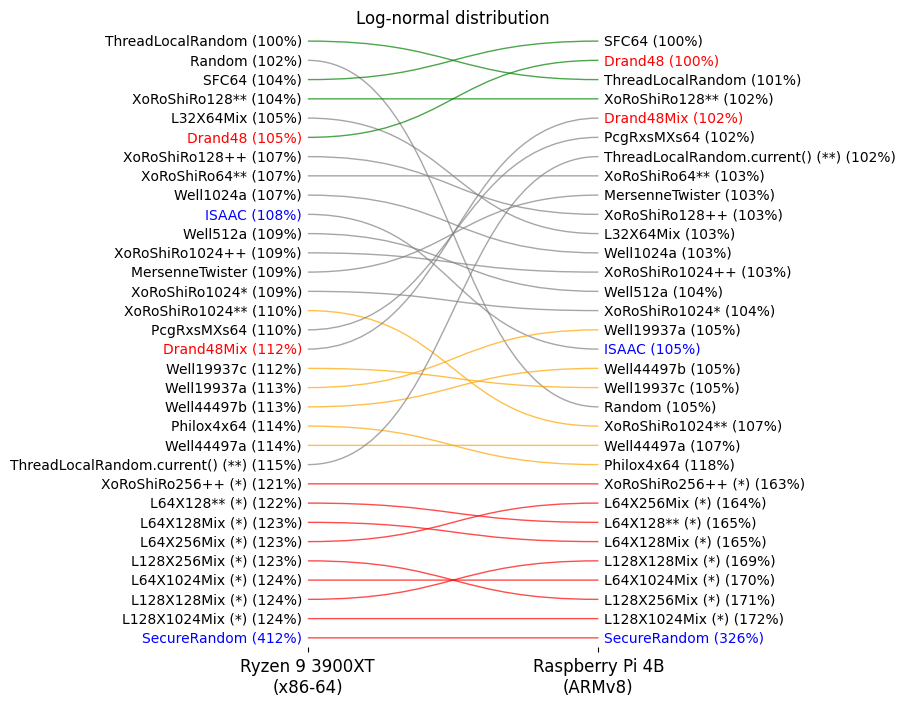

In [24]:
fig = build_diagram_from_rec(amd_arm["input"][1], amd_arm["platform_other"])

# fig.savefig("plot1platforms-Arm-Log.png", format="png", bbox_inches='tight', pad_inches=0)

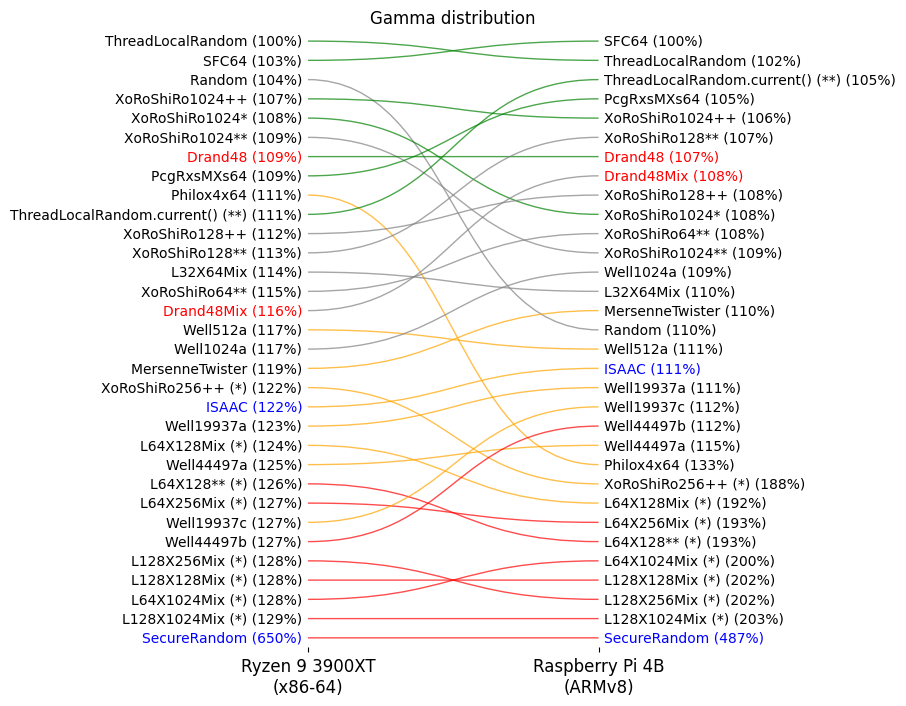

In [ ]:
fig = build_diagram_from_rec(amd_arm["input"][2], amd_arm["platform_other"])

# fig.savefig("plot1platforms-Arm-Gamma.png", format="png", bbox_inches='tight', pad_inches=0)

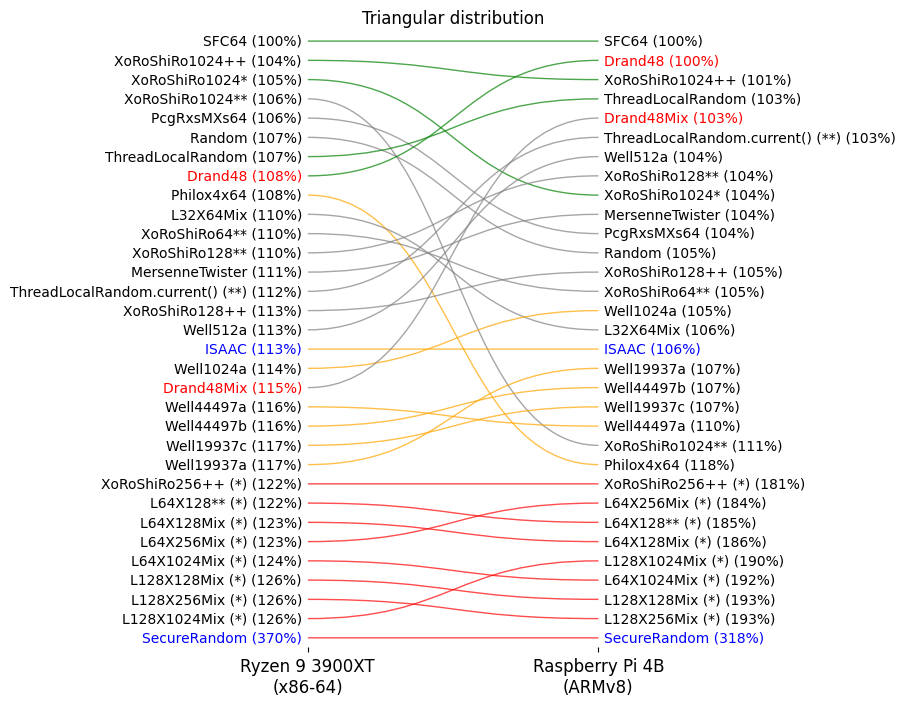

In [26]:
fig = build_diagram_from_rec(amd_arm["input"][3], amd_arm["platform_other"])

# fig.savefig("plot1platforms-Arm-Triangular.png", format="png", bbox_inches='tight', pad_inches=0)

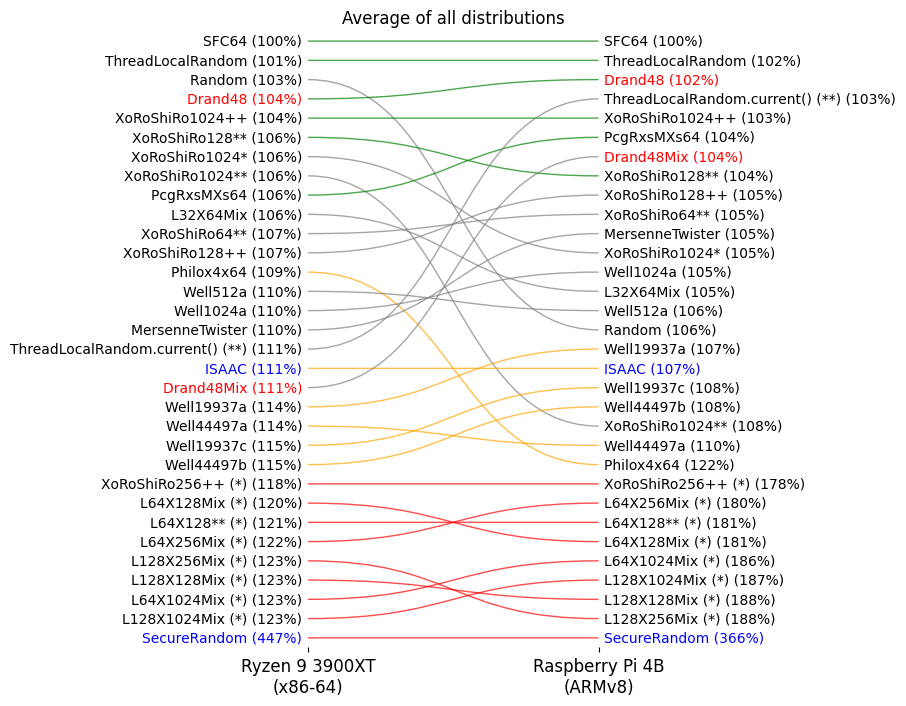

In [ ]:
fig = build_diagram_from_rec(amd_arm["average"], amd_arm["platform_other"])

# fig.savefig("plot1platforms-Arm-Combined.png", format="png", bbox_inches='tight', pad_inches=0)

# fig.savefig("PRNG-DES-Benchmarks-Figures-plot1platforms-Arm.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

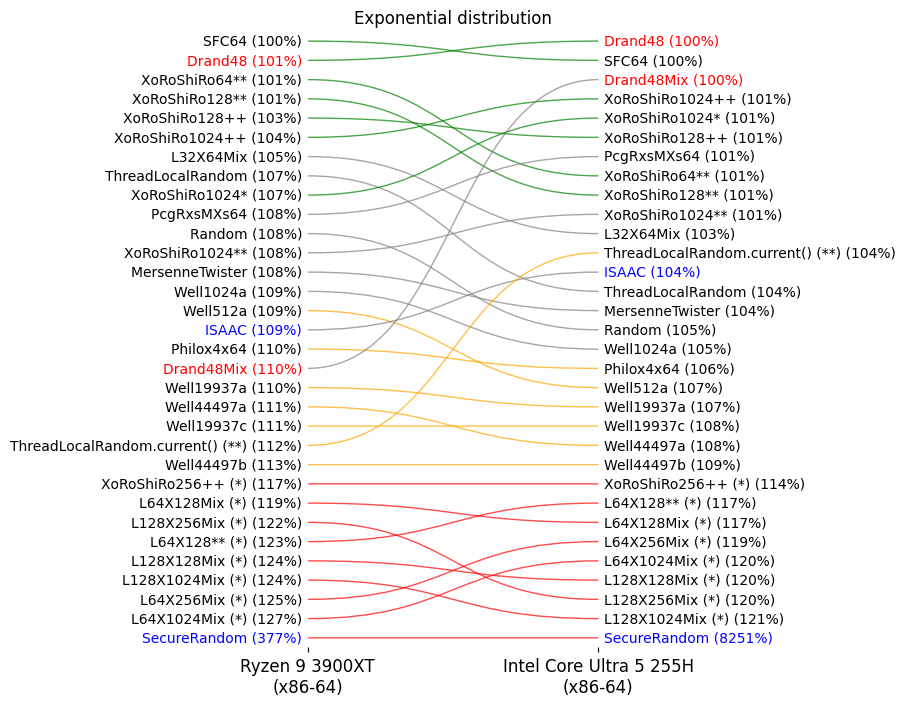

In [28]:
fig = build_diagram_from_rec(amd_intel["input"][0], amd_intel["platform_other"])

# fig.savefig("plot1platforms-Intel-Exp.png", format="png", bbox_inches='tight', pad_inches=0)

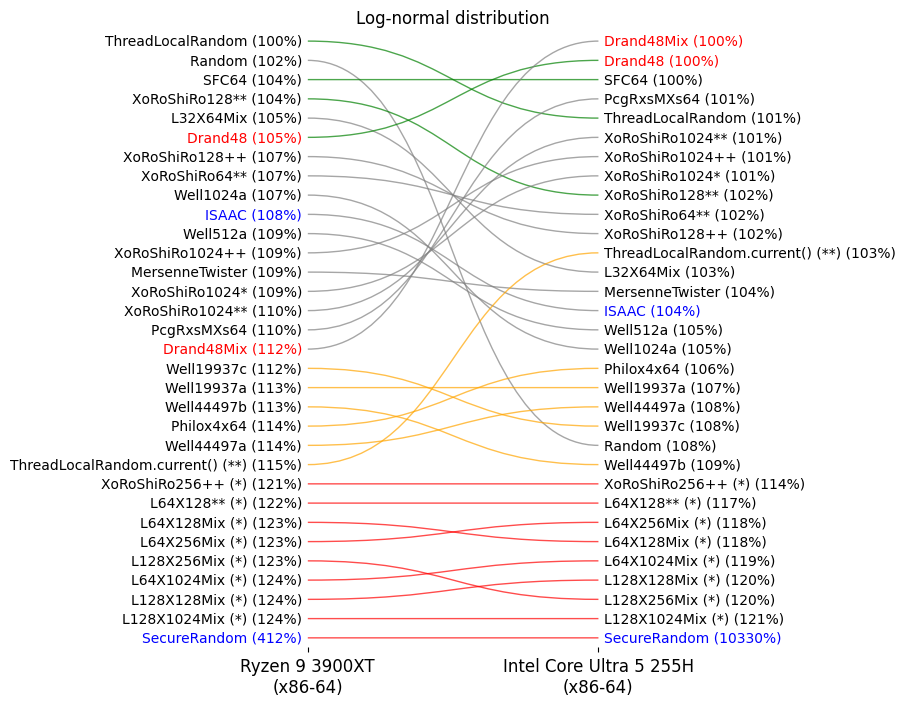

In [29]:
fig = build_diagram_from_rec(amd_intel["input"][1], amd_intel["platform_other"])

# fig.savefig("plot1platforms-Intel-Log.png", format="png", bbox_inches='tight', pad_inches=0)

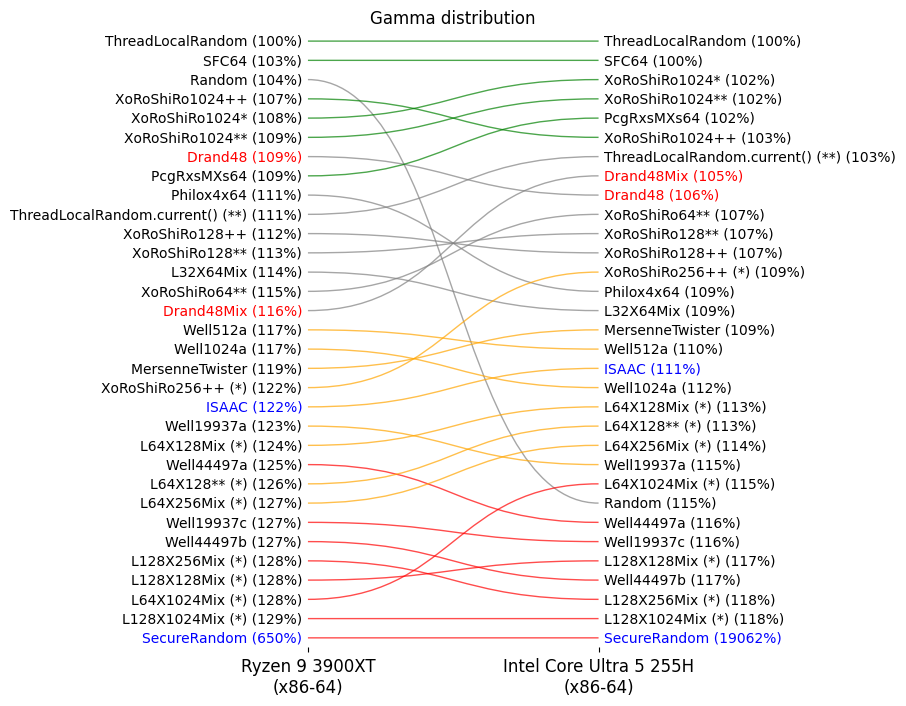

In [30]:
fig = build_diagram_from_rec(amd_intel["input"][2], amd_intel["platform_other"])

# fig.savefig("plot1platforms-Intel-Gamma.png", format="png", bbox_inches='tight', pad_inches=0)

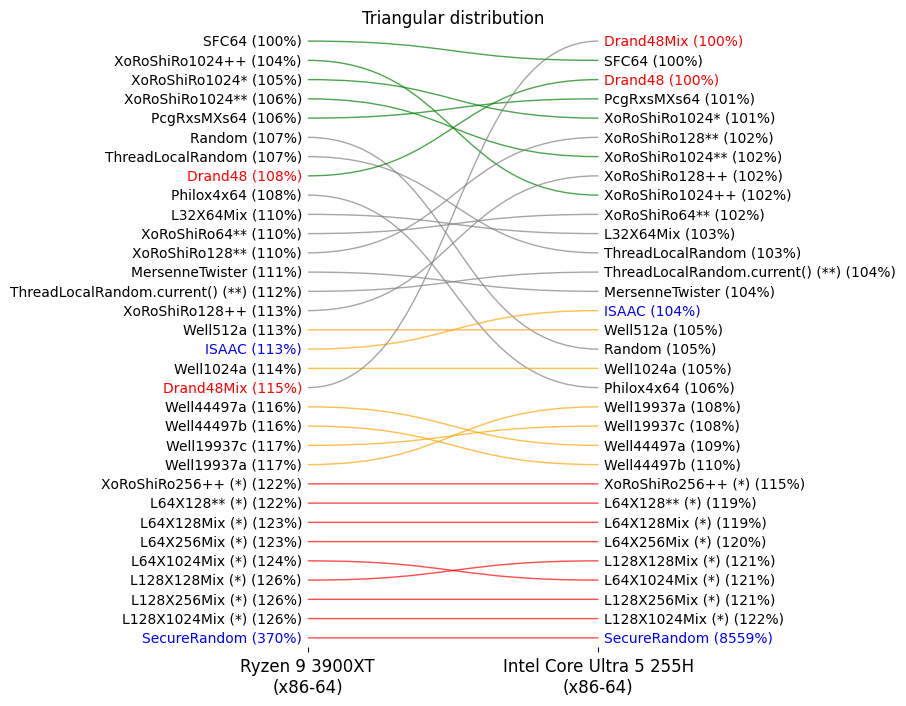

In [31]:
fig = build_diagram_from_rec(amd_intel["input"][3], amd_intel["platform_other"])

# fig.savefig("plot1platforms-Intel-Triangular.png", format="png", bbox_inches='tight', pad_inches=0)

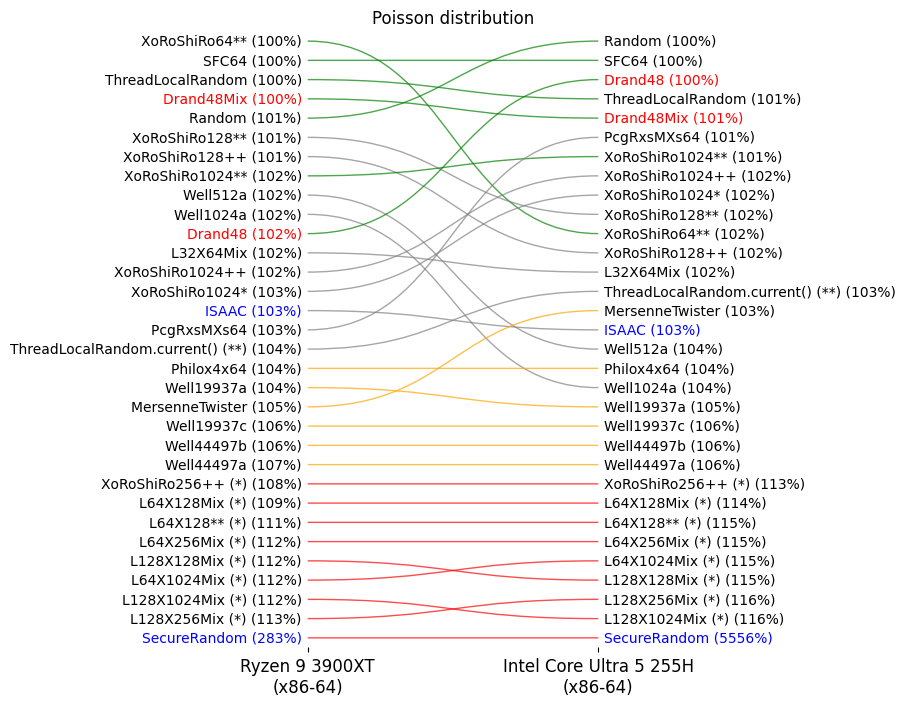

In [32]:
fig = build_diagram_from_rec(amd_intel["input"][4], amd_intel["platform_other"])

# fig.savefig("plot1platforms-Intel-Poisson.png", format="png", bbox_inches='tight', pad_inches=0)

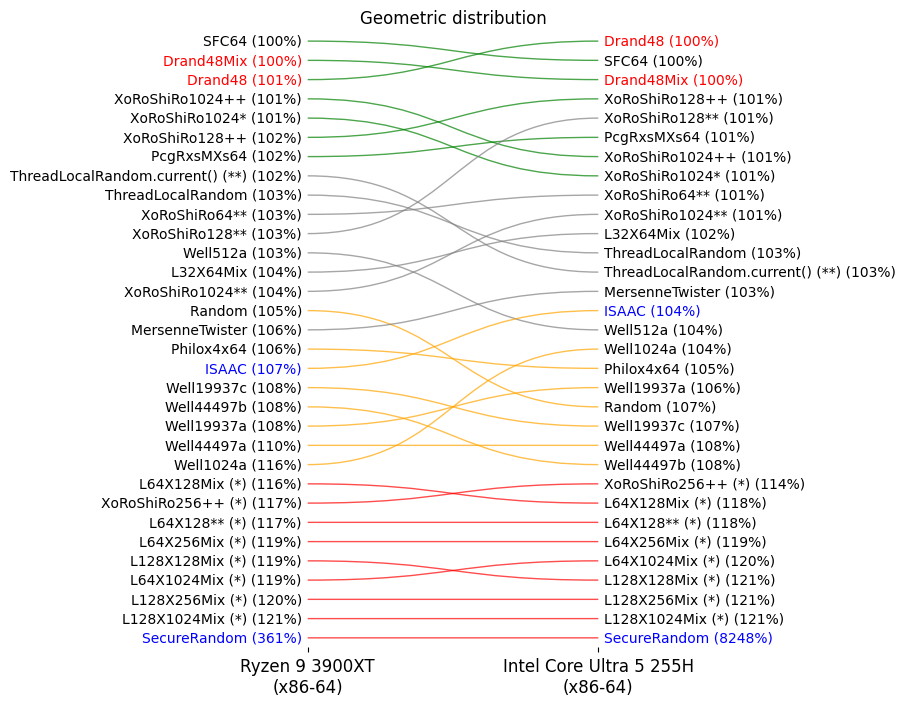

In [33]:
fig = build_diagram_from_rec(amd_intel["input"][5], amd_intel["platform_other"])

# fig.savefig("plot1platforms-Intel-Geometric.png", format="png", bbox_inches='tight', pad_inches=0)

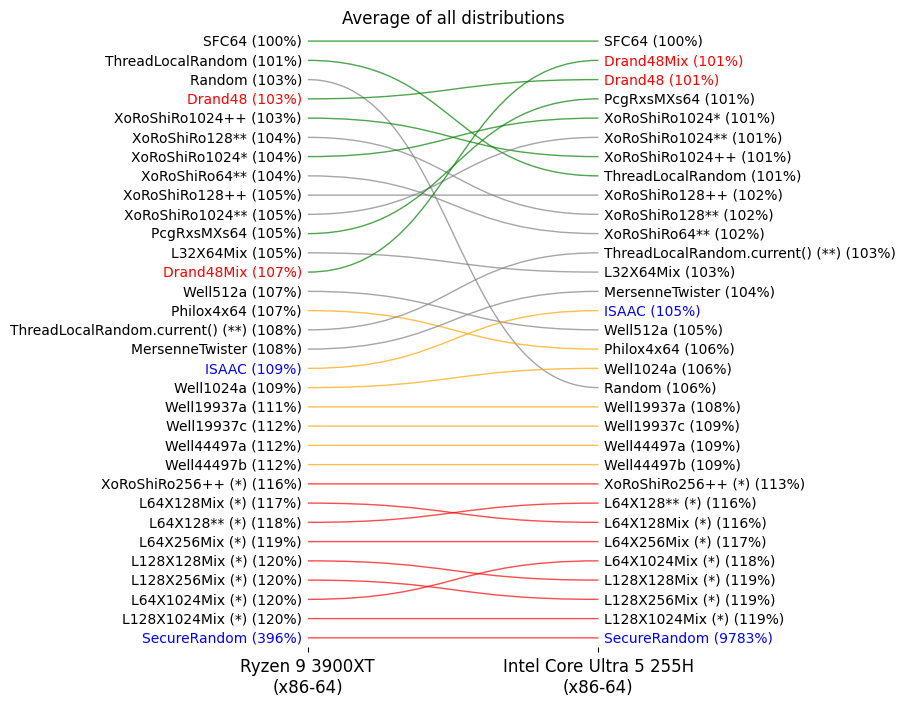

In [34]:
fig = build_diagram_from_rec(amd_intel["average"], amd_intel["platform_other"])

# fig.savefig("plot1platforms-Intel-Combined.png", format="png", bbox_inches='tight', pad_inches=0)

# fig.savefig("PRNG-DES-Benchmarks-Figures-plot1platforms-Intel.pdf", format="pdf", bbox_inches='tight', pad_inches=0)